In [74]:
import h5py
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas
import pandas as pd
from chainconsumer import Chain, ChainConsumer, PlotConfig
from numpyro.infer import MCMC, NUTS

In [75]:
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/"

in_flag = True  # True for in-situ, False for ex-situ
snapz0 = 600

In [76]:
ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
timez0 = np.array(pub_data["time_Gyr"])[-1]
timez0

np.float64(13.798746883)

In [77]:
prop_dict = {"mfor": np.array([]), "mz0": np.array([]), "pz0": np.array([]), "age": np.array([])}

for it_id in ghost_data.keys():
    src_dat = ghost_data[it_id]["source"]

    smsk = src_dat["s_flag"][()].astype(bool)
    if in_flag:
        amsk = src_dat["grpid"][()] == 0
    else:
        amsk = src_dat["grpid"][()] != 0
    msk = smsk & amsk

    mfor = 10 ** src_dat["logm_tfor"][msk]
    mz0 = 10 ** src_dat["logm_tz0"][msk]
    pz0 = src_dat["torb_600"][msk]
    age = timez0 - src_dat["tfor"][msk]

    prop_dict["mfor"] = np.append(prop_dict["mfor"], mfor)
    prop_dict["mz0"] = np.append(prop_dict["mz0"], mz0)
    prop_dict["pz0"] = np.append(prop_dict["pz0"], pz0)
    prop_dict["age"] = np.append(prop_dict["age"], age)

In [78]:
def gc_forward_model(mfor, mz0, pz0, age):
    """
    Forward (generative) model calibrated on simulations.
    """

    # -------- log-transform all physical quantities --------
    log_mfor = jnp.log10(mfor)
    log_mz0 = jnp.log10(mz0)
    log_age = jnp.log10(age)
    log_pz0 = jnp.log10(pz0)

    # -------- priors: mass-loss model parameters --------
    a = numpyro.sample("a", dist.Normal(0.0, 1.0))  # age dependence
    b = numpyro.sample("b", dist.Normal(0.0, 1.0))  # tidal/environment dependence
    c = numpyro.sample("c", dist.Normal(0.0, 1.0))  # normalization

    # Intrinsic physical scatter (degeneracy)
    sigma_int = numpyro.sample("sigma_int", dist.HalfNormal(0.5))

    # -------- deterministic forward prediction --------
    mu_loss = a * log_age + b * log_pz0 + c
    # log_mz0_model = log_mfor - jnp.log10(mu_loss)
    log_mz0_model = log_mfor - mu_loss

    # -------- likelihood --------
    with numpyro.plate("gc", len(mz0)):
        numpyro.sample("mz0_obs", dist.Normal(log_mz0_model, sigma_int), obs=log_mz0)

In [79]:
# Set up HMC
nuts_kernel = NUTS(gc_forward_model)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=10000)

# Run inference
rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key, mfor=prop_dict["mfor"], mz0=prop_dict["mz0"], pz0=prop_dict["pz0"], age=prop_dict["age"])

# Extract posterior samples
posterior = mcmc.get_samples()
mcmc.print_summary()

sample: 100%|██████████| 11000/11000 [00:30<00:00, 366.06it/s, 27 steps of size 4.52e-02. acc. prob=0.88] 


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.38      0.07      0.38      0.27      0.49   2584.21      1.00
          b     -0.11      0.01     -0.11     -0.12     -0.09   5057.79      1.00
          c      0.56      0.06      0.55      0.45      0.66   2683.24      1.00
  sigma_int      0.34      0.00      0.34      0.34      0.35   5887.12      1.00

Number of divergences: 0


In [84]:
df = pd.DataFrame(
    {
        "a": posterior["a"],
        "b": posterior["b"],
        "c": posterior["c"],
        "sigma_int": posterior["sigma_int"],
    }
)


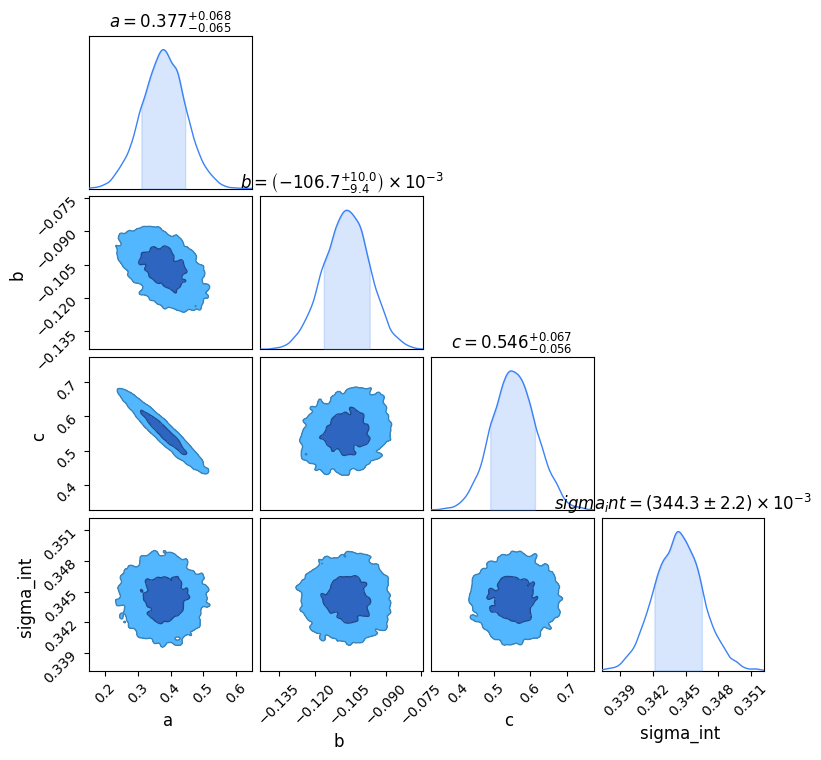

In [85]:
C = ChainConsumer()

C.add_chain(Chain(samples=df, name="Forward model (simulation-calibrated)"))

C.set_plot_config(
    PlotConfig(
        diagonal_tick_labels=True,
        shade=True,
        shade_alpha=0.4,
        sigma2d=True,
        flip=False,
    )
)

fig = C.plotter.plot(figsize=(8, 8))

In [86]:
summary = C.analysis.get_summary()
print(summary)

{'Forward model (simulation-calibrated)': {'a': Bound(lower=0.31137402726143715, center=0.37675711559447644, upper=0.44449989433352016), 'b': Bound(lower=-0.11614874788973793, center=-0.10673611618016052, upper=-0.09676939786558617), 'c': Bound(lower=0.4895895838183109, center=0.545790004835975, upper=0.6125892374243236), 'sigma_int': Bound(lower=0.3421423778318705, center=0.3443398908054036, upper=0.34650464952052357)}}


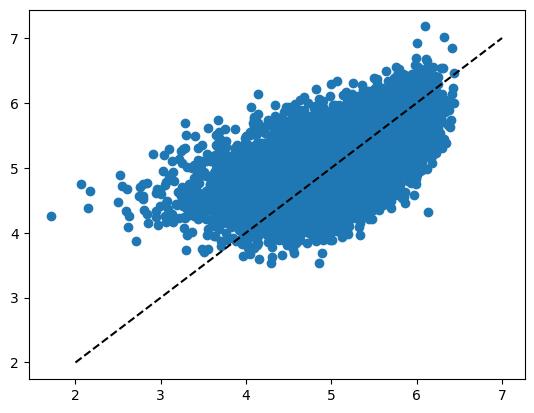

In [100]:
samples = mcmc.get_samples()

i = np.random.choice(len(samples["a"]))
mu = np.log10(prop_dict["mfor"]) - (
    samples["a"][i] * np.log10(prop_dict["age"])
    + samples["b"][i] * np.log10(prop_dict["pz0"])
    + samples["c"][i]
)
eps = np.random.normal(0, samples["sigma_int"][i], size=len(mu))
log_mz0_pp = mu + eps

plt.scatter(np.log10(prop_dict["mz0"]), log_mz0_pp)
plt.plot([2, 7], [2, 7], "k--")

Text(0, 0.5, 'Posterior predictive log10(m_for)')

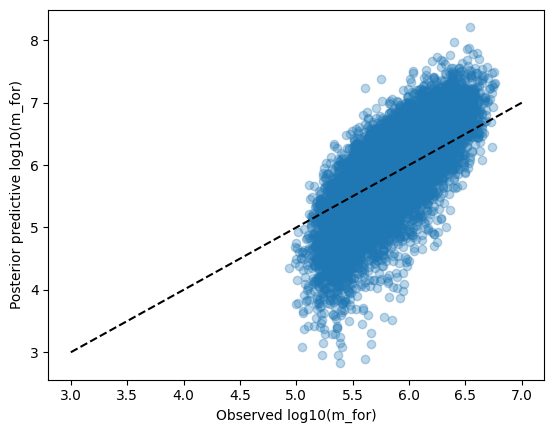

In [119]:
i = np.random.choice(len(samples["a"]))

log_mfor_pp = (
    np.log10(prop_dict["mz0"])
    + samples["a"][i] * np.log10(prop_dict["age"])
    + samples["b"][i] * np.log10(prop_dict["pz0"])
    + samples["c"][i]
    - np.random.normal(0, samples["sigma_int"][i], size=len(prop_dict["mz0"]))
)


plt.scatter(np.log10(prop_dict["mfor"]), log_mfor_pp, alpha=0.3)
plt.plot([3, 7], [3, 7], "k--")
plt.xlabel("Observed log10(m_for)")
plt.ylabel("Posterior predictive log10(m_for)")


np.float64(-1231503.6667710904)

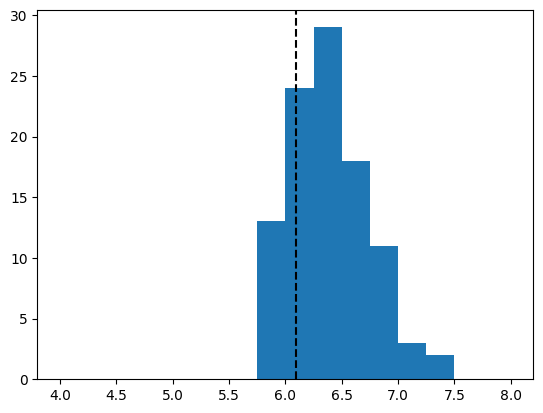

In [207]:
k = 31
n = 100
log_mfors = []

indices = np.random.randint(0, len(samples["a"]), size=n)

for i in indices:
    log_mfor = (
        np.log10(prop_dict["mz0"][k])
        + samples["a"][i] * np.log10(prop_dict["age"][k])
        + samples["b"][i] * np.log10(prop_dict["pz0"][k])
        + samples["c"][i]
        - np.random.normal(0, samples["sigma_int"][i])  # scalar noise
    )
    log_mfors.append(log_mfor)

log_mfors = np.array(log_mfors)


bins = np.arange(4, 8.25, 0.25)
plt.hist(log_mfors, bins=bins)
plt.axvline(np.log10(prop_dict["mfor"][k]), c="k", ls="--")

prop_dict["mfor"][k] - 10 ** np.mean(log_mfors)

In [203]:
np.percentile(log_mfors, 50)

np.float32(6.5366163)

In [ ]:
# # k = 1
# n = 100
# diff = []
# for k in range(0, 100):
#     log_mfors = []

#     indices = np.random.randint(0, len(samples["a"]), size=n)

#     for i in indices:
#         log_mfor = (
#             np.log10(prop_dict["mz0"][k])
#             + samples["a"][i] * np.log10(prop_dict["age"][k])
#             + samples["b"][i] * np.log10(prop_dict["pz0"][k])
#             + samples["c"][i]
#             - np.random.normal(0, samples["sigma_int"][i])  # scalar noise
#         )
#         log_mfors.append(log_mfor)

#     log_mfors = np.array(log_mfors)
#     log_mfor_med = np.median(log_mfors)
#     diff.append(np.abs(prop_dict["mfor"][k] - 10**log_mfor_med) / prop_dict["mfor"][k])

In [209]:
n = 100

mass_dict = {"mean": [], "median": [], "std": [], "per25": [], "per75": []}

for k in range(0, len(prop_dict["mfor"])):
    print(k + 1, "/", len(prop_dict["mfor"]))
    log_mfors = []

    indices = np.random.randint(0, len(samples["a"]), size=n)

    for i in indices:
        log_mfor = (
            np.log10(prop_dict["mz0"][k])
            + samples["a"][i] * np.log10(prop_dict["age"][k])
            + samples["b"][i] * np.log10(prop_dict["pz0"][k])
            + samples["c"][i]
            - np.random.normal(0, samples["sigma_int"][i])  # scalar noise
        )
        log_mfors.append(log_mfor)

    log_mfors = np.array(log_mfors)

    mass_dict["mean"].append(np.mean(log_mfors))
    mass_dict["median"].append(np.median(log_mfors))
    mass_dict["std"].append(np.std(log_mfors))
    mass_dict["per25"].append(np.percentile(log_mfors, 25))
    mass_dict["per75"].append(np.percentile(log_mfors, 75))

1 / 12483
2 / 12483
3 / 12483
4 / 12483
5 / 12483
6 / 12483
7 / 12483
8 / 12483
9 / 12483
10 / 12483
11 / 12483
12 / 12483
13 / 12483
14 / 12483
15 / 12483
16 / 12483
17 / 12483
18 / 12483
19 / 12483
20 / 12483
21 / 12483
22 / 12483
23 / 12483
24 / 12483
25 / 12483
26 / 12483
27 / 12483
28 / 12483
29 / 12483
30 / 12483
31 / 12483
32 / 12483
33 / 12483
34 / 12483
35 / 12483
36 / 12483
37 / 12483
38 / 12483
39 / 12483
40 / 12483
41 / 12483
42 / 12483
43 / 12483
44 / 12483
45 / 12483
46 / 12483
47 / 12483
48 / 12483
49 / 12483
50 / 12483
51 / 12483
52 / 12483
53 / 12483
54 / 12483
55 / 12483
56 / 12483
57 / 12483
58 / 12483
59 / 12483
60 / 12483
61 / 12483
62 / 12483
63 / 12483
64 / 12483
65 / 12483
66 / 12483
67 / 12483
68 / 12483
69 / 12483
70 / 12483
71 / 12483
72 / 12483
73 / 12483
74 / 12483
75 / 12483
76 / 12483
77 / 12483
78 / 12483
79 / 12483
80 / 12483
81 / 12483
82 / 12483
83 / 12483
84 / 12483
85 / 12483
86 / 12483
87 / 12483
88 / 12483
89 / 12483
90 / 12483
91 / 12483
92 / 124

(array([  18.,  159.,  725., 1491., 1841., 1906., 1915., 1768., 1567.,
        1093.]),
 array([-2.14102956, -1.82704051, -1.51305147, -1.19906243, -0.88507338,
        -0.57108434, -0.25709529,  0.05689375,  0.3708828 ,  0.68487184,
         0.99886089]),
 <BarContainer object of 10 artists>)

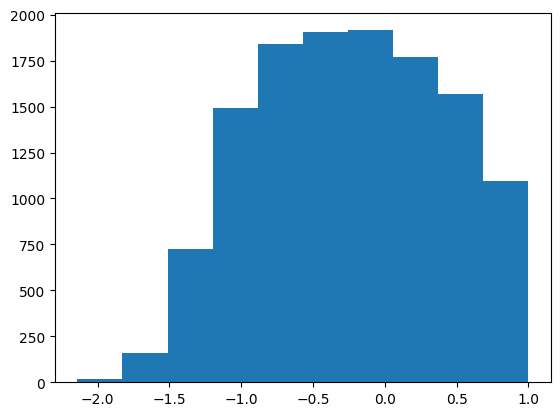

In [228]:
diff = (prop_dict["mfor"] - 10 ** np.array(mass_dict["mean"])) / prop_dict["mfor"]
plt.hist(diff)

Text(0, 0.5, 'Formation Mass\n(fractional difference model vs expected)')

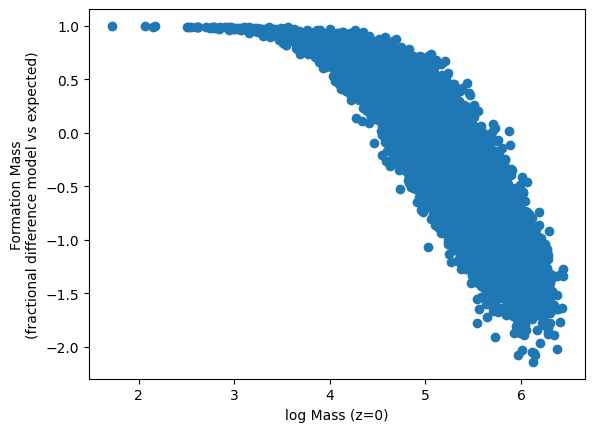

In [238]:
plt.scatter(np.log10(prop_dict["mz0"]), diff)
plt.xlabel("log Mass (z=0)")
plt.ylabel(r"Formation Mass" + "\n" + "(fractional difference model vs expected)")

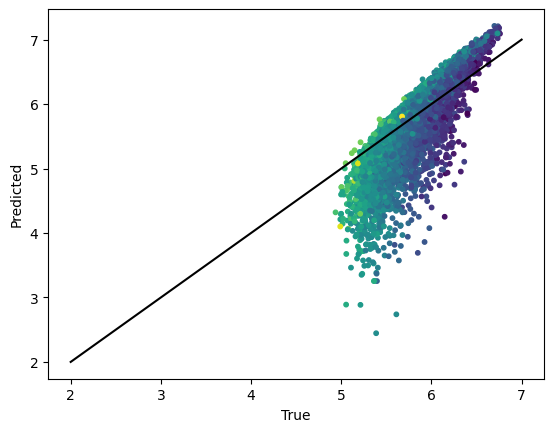

In [222]:
# plt.scatter(np.log10(prop_dict["mfor"]), mass_dict["mean"], s=10)
plt.scatter(np.log10(prop_dict["mfor"]), mass_dict["median"], s=10, c=np.log10(prop_dict["pz0"]))
# plt.errorbar(np.log10(prop_dict["mfor"]), mass_dict["mean"], yerr=mass_dict["std"], c="grey", fmt="o")

plt.xlabel("True")
plt.ylabel("Predicted")

plt.plot([2, 7], [2, 7], c="k")